In [1]:
from pathlib import Path

import itertools
import matplotlib as mpl
import numpy as np
import polars as pl
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.axes import Axes

from emevo.analysis import Tree
from emevo.analysis.log_plotting import load_log, plot_rewards_3d

In [ ]:
logd = log_directory
rew = pl.read_parquet(logd / "profile_and_rewards.parquet")
log = log_log(log)

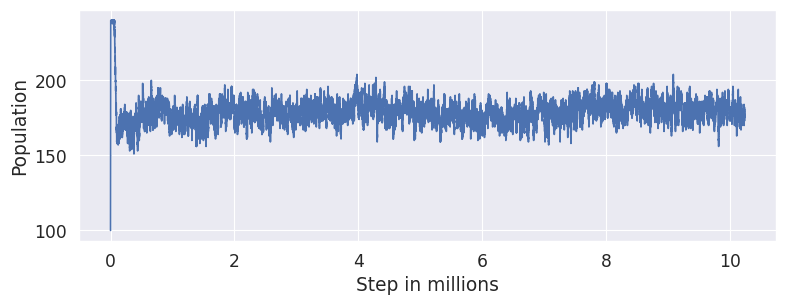

In [17]:
sns.set_theme()
sns.set_context("paper", font_scale=1.4)
population = (
    log.group_by("step")
    .agg(pl.col("unique_id").len().alias("Population"))
    .with_columns((pl.col("step") / 1e6).alias("Step in millions"))
)
# ax.set_title(f"Population {key}")
sns.lineplot(
    x="Step in millions",
    y="Population",
    data=population.filter(pl.col("step") % 100 == 0).collect(),
)

In [ ]:
sns.lineplot(
    x="Step in millions",
    y="Energy Consumption",
    data=log.group_by("step")
    .agg(pl.mean("consumed_energy").alias("Energy Consumption"))
    .filter(pl.col("step") % 100 == 0)
    .collect(),
)